# Customer and Segment Analysis

## Objective

This part looks at the bank's customer portfolio after cleaning the data.

Main questions:

- who the customers are
- which customer groups are most common
- which customer segments hold stronger income and deposit value
- how loyalty tier relates to customer value
- whether credit utilization looks healthy or risky

This uses the clean customer-level dataset from the preparation step.



## 1. Import Libraries and Load Customer Data

We load `banking_customer_profiles_clean.csv`, which has one row per customer. This dataset is used for customer portfolio and segmentation analysis.


In [5]:
# Basic libraries used in this notebook
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="darkgrid", palette="deep")

# Find the project folder automatically.
cwd = Path.cwd().resolve()
project_root = cwd
while project_root != project_root.parent and not (project_root / "data" / "processed").exists():
    project_root = project_root.parent

processed_dir = project_root / "data" / "processed"
tables_dir = project_root / "reports" / "tables"
figures_dir = project_root / "reports" / "figures" / "customer_segments"

for folder in [tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# Add the project root to Python path so notebook can import helpers from src/.
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.eda_utils import add_percentage_column, export_tables, plot_donut_chart

print("Project root:", project_root)
print("Processed data folder:", processed_dir)

# Load the customer-level clean dataset from EDA 1.
customer_data_path = processed_dir / "banking_customer_profiles_clean.csv"
df = pd.read_csv(customer_data_path, parse_dates=["joined_bank"])

print(f"Loaded {len(df):,} customers and {df.shape[1]} columns.")
df.head()

segment_order = ["Retail", "Priority", "Private Banking"]
df["customer_segment"] = pd.Categorical(
    df["customer_segment"],
    categories=segment_order,
    ordered=True,
)

assert set(df["customer_segment"].dropna().astype("string").unique()) == set(segment_order)#heret emp converting to string 
assert "banking_relationship" not in df.columns


Project root: C:\tmp\Data_Analytics_publish_fresh\Projects\Banking-Customer-Risk-Intelligence
Processed data folder: C:\tmp\Data_Analytics_publish_fresh\Projects\Banking-Customer-Risk-Intelligence\data\processed
Loaded 15,000 customers and 30 columns.


## 2. Basic Customer Portfolio KPIs

This section gives the first high-level view of the customer base.


In [6]:
# Create high-level customer KPIs.
customer_kpis = pd.DataFrame([
    {"metric": "Total customers", "value": len(df)},
    {"metric": "Median age", "value": round(df["age"].median(), 1)},
    {"metric": "Median annual income", "value": round(df["annual_income"].median(), 2)},
    {"metric": "Median total deposits", "value": round(df["total_deposit_balance"].median(), 2)},
    {"metric": "Average tenure years", "value": round(df["customer_tenure_years"].mean(), 1)},
])

customer_kpis


,metric,value
0,Total customers,"15,000.00"
1,Median age,47.00
2,Median annual income,"874,386.72"
3,Median total deposits,"2,344,103.97"
4,Average tenure years,14.30


## 3. Age Group Analysis

Age groups help us understand whether the bank mostly serves younger, working-age, mature, or retired customers.


In [7]:
# Summarize customer count, income, deposits, and credit utilization by age group.
age_group_summary = (
    df.groupby("age_group", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
    )
    .reset_index()
)

age_group_summary = add_percentage_column(age_group_summary, "customers", len(df))
age_group_summary


,age_group,customers,median_income,median_deposits,median_credit_utilization,customer_pct
0,18-25,739,"861,188.69","2,316,955.23",0.22,4.93
1,26-35,2059,"888,547.69","2,371,402.37",0.21,13.73
2,36-45,4099,"882,348.89","2,397,827.46",0.21,27.33
3,46-55,4351,"874,386.72","2,306,704.63",0.22,29.01
4,56-65,2610,"865,606.38","2,296,903.75",0.22,17.40
5,66+,1142,"868,404.72","2,298,297.95",0.22,7.61


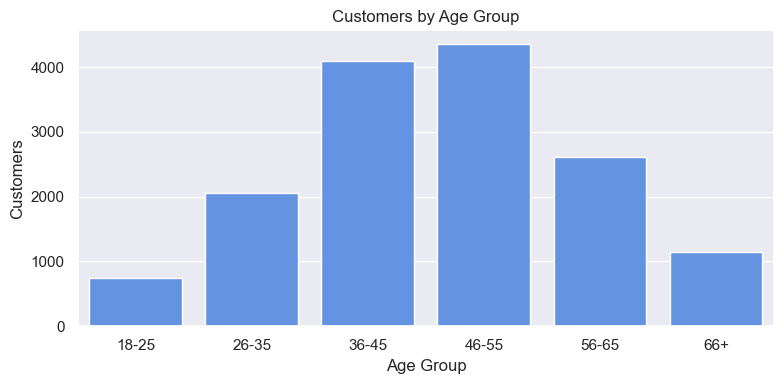

In [8]:
# Plot customer count by age group.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=age_group_summary, x="age_group", y="customers", ax=ax, color="#4f8ef7")
ax.set_title("Customers by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(figures_dir / "customers_by_age_group.png", dpi=160, bbox_inches="tight")
plt.show()


## 4. Gender Distribution

Gender is checked to understand customer distribution. It is not used alone as a risk decision factor; here it is only for portfolio description.


In [9]:
# Gender-wise customer count and financial profile.
gender_summary = (
    df.groupby("gender", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
    )
    .reset_index()
)

gender_summary = add_percentage_column(gender_summary, "customers", len(df))
gender_summary


,gender,customers,median_income,median_deposits,median_credit_utilization,customer_pct
0,Female,6955,"874,386.72","2,360,288.10",0.22,46.37
1,Male,8045,"874,386.72","2,336,237.44",0.21,53.63


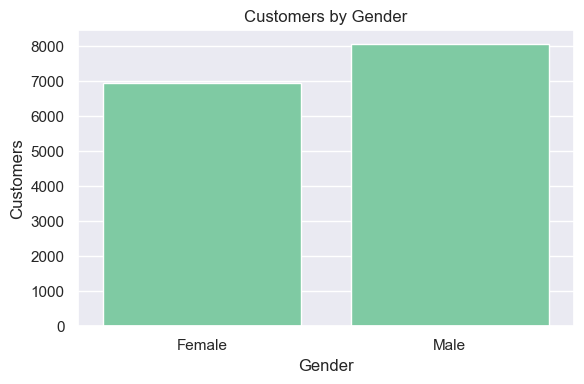

In [10]:
# Plot gender distribution.
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=gender_summary, x="gender", y="customers", ax=ax, color="#72d6a3")
ax.set_title("Customers by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(figures_dir / "gender_percentage.png", dpi=160, bbox_inches="tight")
plt.show()


## 5. Occupation and Employment Analysis

Occupation and employment status help explain customer income patterns and banking needs.


In [11]:
# Top occupations by customer count.
occupation_summary = (
    df.groupby("occupation", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

# Employment status summary.
employment_summary = (
    df.groupby("employment_status", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

occupation_summary = add_percentage_column(occupation_summary, "customers", len(df))
employment_summary = add_percentage_column(employment_summary, "customers", len(df))

display(occupation_summary.head(10))
display(employment_summary)


,occupation,customers,median_income,median_deposits,customer_pct
0,Self Employed,879,"874,386.72","2,304,535.35",5.86
1,Retired,877,"882,612.94","2,413,327.43",5.85
2,Doctor,857,"890,030.93","2,461,199.72",5.71
3,Software Engineer,845,"881,398.42","2,348,471.71",5.63
4,Consultant,838,"887,507.10","2,309,975.30",5.59
5,Sales Manager,836,"864,546.45","2,268,156.92",5.57
6,Factory Supervisor,831,"874,386.72","2,351,409.49",5.54
7,Teacher,826,"874,386.72","2,332,605.04",5.51
8,Business Owner,823,"873,539.59","2,241,818.07",5.49
9,Shop Owner,822,"912,710.15","2,512,022.33",5.48


,employment_status,customers,median_income,median_deposits,customer_pct
0,Salaried,7102,"855,377.05","2,294,667.57",47.35
1,Self Employed,2749,"932,923.67","2,533,644.87",18.33
2,Business Owner,2661,"1,081,946.80","2,862,265.01",17.74
3,Retired,1191,"623,059.81","1,684,282.22",7.94
4,Contract,1177,"727,062.93","1,935,261.01",7.85
5,Unknown,120,"837,175.53","2,010,297.65",0.80


I analyzed occupation and employment because income stability matters in banking. Stable employment groups can be better for lending, while high-income professions may be valuable for deposits, advisory services and premium banking products

## 6. Customer Segment Analysis

`customer_segment` is the service tier through which the bank manages an individual customer:

- **Retail:** standard deposits, cards, and personal lending products
- **Priority:** enhanced service and preferential benefits for affluent customers
- **Private Banking:** personalized banking, wealth, and relationship-management services for high-value customers

Loyalty tier is analyzed separately because it measures engagement rather than service tier.


In [12]:
# Customer service segment summary.
customer_segment_summary = (
    df.groupby("customer_segment", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
        median_tenure_years=("customer_tenure_years", "median"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

customer_segment_summary = add_percentage_column(customer_segment_summary, "customers", len(df))
customer_segment_summary


,customer_segment,customers,median_income,median_deposits,median_credit_utilization,median_tenure_years,customer_pct
0,Retail,7821,"753,706.67","2,012,534.87",0.22,14.30,52.14
1,Priority,3683,"958,939.13","2,587,762.84",0.21,14.00,24.55
2,Private Banking,3496,"1,108,769.58","2,957,191.09",0.21,14.30,23.31


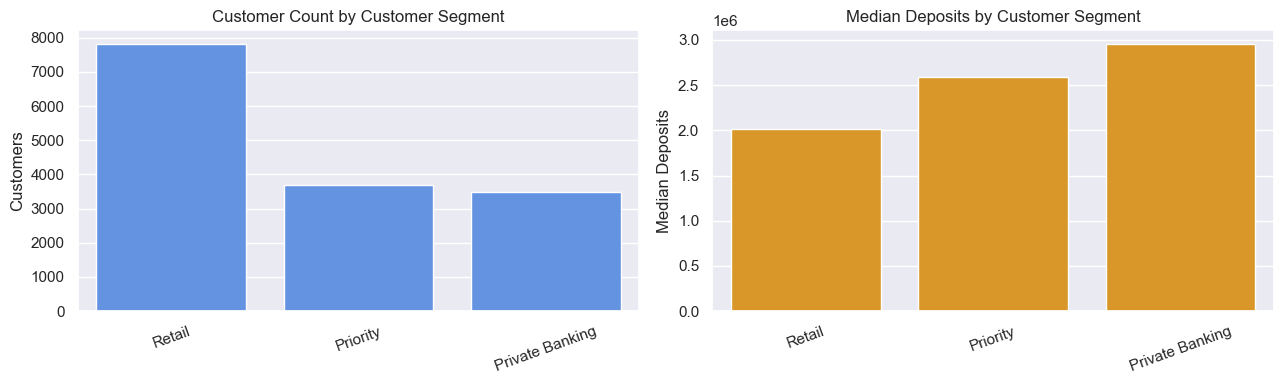

In [13]:
# Plot segment size and median deposits side by side.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=customer_segment_summary, x="customer_segment", y="customers", order=segment_order, ax=axes[0], color="#4f8ef7")
axes[0].set_title("Customer Count by Customer Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")

sns.barplot(data=customer_segment_summary, x="customer_segment", y="median_deposits", order=segment_order, ax=axes[1], color="#f59e0b")
axes[1].set_title("Median Deposits by Customer Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Deposits")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(figures_dir / "customer_segment_summary.png", dpi=160, bbox_inches="tight")
plt.show()


### Customer Segment Result
I analyzed customer segments because banks do not treat all customers the same. Retail customers help with scale, Priority customers may give stronger relationship value, and Private Banking customers usually need premium service and personalized financial planning. This helps the bank decide where to focus service, offers and relationship management.


## 7. Loyalty Tier Analysis

Loyalty tier is checked to see whether long-term or premium customers hold stronger deposit value.


In [14]:
# Loyalty tier summary.
loyalty_summary = (
    df.groupby("loyalty_classification", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_tenure_years=("customer_tenure_years", "median"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .sort_values("median_deposits", ascending=False)
    .reset_index()
)

loyalty_summary = add_percentage_column(loyalty_summary, "customers", len(df))
loyalty_summary


,loyalty_classification,customers,median_tenure_years,median_income,median_deposits,customer_pct
0,Platinum,1954,14.80,"1,172,548.90","4,902,203.87",13.03
1,Gold,3716,14.10,"952,596.50","2,989,521.35",24.77
2,Silver,4540,14.00,"828,441.49","2,148,981.08",30.27
3,Jade,4790,14.30,"773,544.98","1,673,124.54",31.93


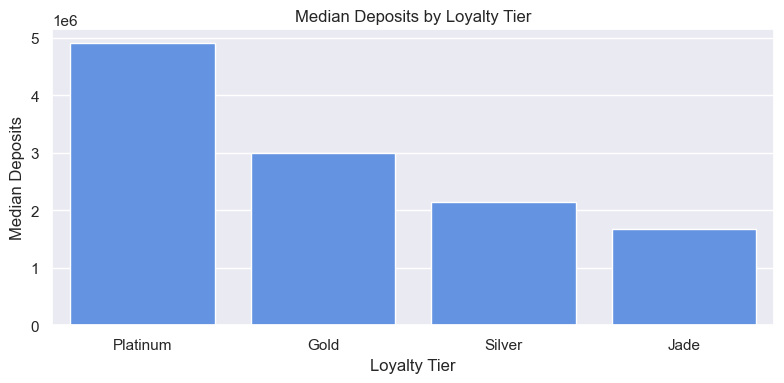

In [15]:
# Plot median deposits by loyalty tier.
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(data=loyalty_summary, x="loyalty_classification", y="median_deposits", ax=ax, color="#4f8ef7")
ax.set_title("Median Deposits by Loyalty Tier")
ax.set_xlabel("Loyalty Tier")
ax.set_ylabel("Median Deposits")
fig.tight_layout()
fig.savefig(figures_dir / "loyalty_deposit_value.png", dpi=160, bbox_inches="tight")
plt.show()


The loyalty analysis shows that higher loyalty customers are more valuable. Platinum customers are the smallest group but have the highest median income and deposits. This means the bank should protect Platinum and Gold customers with better relationship service, while trying to upgrade Silver and Jade customers through engagement and cross-sell offers

## 8. Income Band and Customer Segment Mix

This section shows how income bands are distributed across Retail, Priority, and Private Banking customers.


In [16]:
# Income band summary.
income_band_summary = (
    df.groupby("income_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        median_credit_utilization=("credit_utilization_ratio", "median"),
    )
    .reset_index()
)

income_band_summary = add_percentage_column(income_band_summary, "customers", len(df))

# Relationship by income band table.
segment_income_summary = (
    df.groupby(["customer_segment", "income_band"], observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .reset_index()
)

display(income_band_summary)
display(segment_income_summary.head(15))


,income_band,customers,median_income,median_deposits,median_credit_utilization,customer_pct
0,Affluent,144,"3,494,126.65","11,598,840.61",0.24,0.96
1,High,2160,"1,831,517.25","5,648,448.29",0.21,14.40
2,Low,958,"334,465.34","810,125.35",0.23,6.39
3,Lower Middle,5441,"609,520.61","1,579,848.13",0.22,36.27
4,Middle,6297,"1,047,938.51","2,929,163.00",0.21,41.98


,customer_segment,income_band,customers,median_income,median_deposits
0,Retail,Affluent,20,"3,225,432.27","10,287,755.80"
1,Retail,High,609,"1,795,333.44","5,814,771.19"
2,Retail,Low,752,"330,786.16","792,817.26"
3,Retail,Lower Middle,3493,"594,404.91","1,570,761.93"
4,Retail,Middle,2947,"1,018,567.93","2,920,142.75"
5,Priority,Affluent,36,"3,641,279.76","11,733,476.88"
6,Priority,High,650,"1,844,244.53","5,664,273.38"
7,Priority,Low,140,"351,098.59","869,120.38"
8,Priority,Lower Middle,1144,"631,316.69","1,594,514.80"
9,Priority,Middle,1713,"1,065,672.14","2,936,109.26"


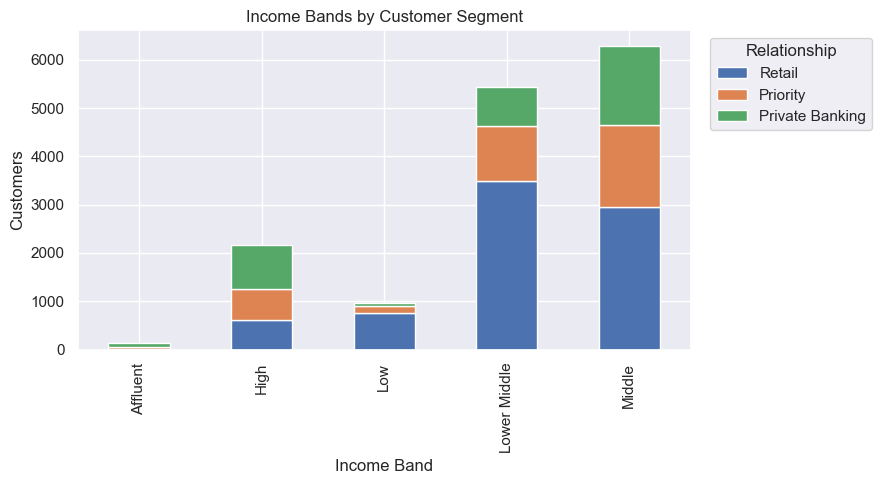

In [17]:
# Stacked chart: income bands by customer segment.
income_segment_pivot = (
    df.groupby(["income_band", "customer_segment"], observed=False)
    .size()
    .unstack(fill_value=0)
)
income_segment_pivot 

fig, ax = plt.subplots(figsize=(9, 5))
income_segment_pivot.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Income Bands by Customer Segment")
ax.set_xlabel("Income Band")
ax.set_ylabel("Customers")
ax.legend(title="Relationship", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / "income_band_by_customer_segment.png", dpi=160, bbox_inches="tight")
plt.show()


### Income Band Result

Income-band analysis shows where customer value sits inside the portfolio and how income groups are distributed across customer segments.



## 9. Credit Utilization Analysis

Credit utilization shows how much of the available credit card limit customers are using. It is useful because very high utilization can indicate financial stress.


In [18]:
# Credit utilization summary.
credit_utilization_summary = (
    df.groupby("credit_utilization_band", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_card_balance=("credit_card_balance", "median"),
        median_credit_limit=("credit_card_limit", "median"),
    )
    .reset_index()
)

credit_utilization_summary = add_percentage_column(credit_utilization_summary, "customers", len(df))
credit_utilization_summary


,credit_utilization_band,customers,median_income,median_card_balance,median_credit_limit,customer_pct
0,High,369,"874,386.72","120,784.22","187,622.72",2.46
1,Low,10257,"874,386.72","24,323.80","179,701.59",68.38
2,Maxed,6,"988,007.47","169,159.26","190,332.38",0.04
3,Moderate,4368,"874,386.72","72,064.49","180,890.77",29.12


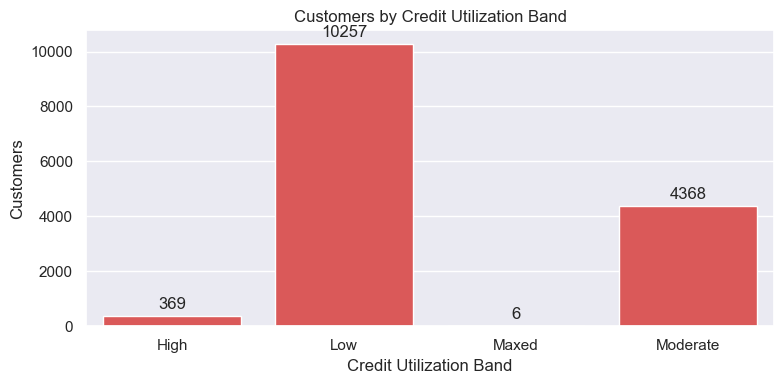

In [ ]:
# Plot credit utilization bands.
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=credit_utilization_summary,
    x="credit_utilization_band",
    y="customers",
    ax=ax,
    color="#ef4444"
)

ax.set_title("Customers by Credit Utilization Band")
ax.set_xlabel("Credit Utilization Band")
ax.set_ylabel("Customers")

# Add count labels so very small groups are still visible.
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

fig.tight_layout()
fig.savefig(figures_dir / "credit_utilization_bands.png", dpi=160, bbox_inches="tight")
plt.show()


## 10. Advisor Portfolio Analysis

Advisor analysis shows how customers and deposit value are distributed across relationship managers/advisors.


In [20]:
# Advisor-wise customer and deposit summary.
advisor_summary = (
    df.groupby("investment_advisor", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        total_deposits=("total_deposit_balance", "sum"),
    )
    .sort_values("customers", ascending=False)
    .reset_index()
)

advisor_summary.head(10)

advisor_segment_summary = (
    df.groupby(["investment_advisor", "customer_segment"], observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
        total_deposits=("total_deposit_balance", "sum"),
    )
    .reset_index()
    .sort_values(["investment_advisor", "customer_segment"])
)

display(advisor_summary.head(10))
display(advisor_segment_summary.head(15))


,investment_advisor,customers,median_income,median_deposits,total_deposits
0,Advisor D,2557,"874,386.72","2,379,802.77","7,755,718,304.01"
1,Advisor A,2546,"874,386.72","2,413,574.58","7,698,696,394.84"
2,Advisor B,2499,"875,203.48","2,368,530.62","7,561,186,323.21"
3,Advisor E,2482,"858,261.47","2,248,827.36","7,355,388,799.79"
4,Advisor C,2465,"874,386.72","2,324,017.19","7,486,156,802.23"
5,Advisor F,2451,"874,386.72","2,332,425.30","7,425,488,021.46"


,investment_advisor,customer_segment,customers,median_income,median_deposits,total_deposits
0,Advisor A,Retail,1323,"760,007.64","2,146,820.24","3,395,200,199.33"
1,Advisor A,Priority,608,"1,005,535.15","2,676,712.84","1,988,358,667.90"
2,Advisor A,Private Banking,615,"1,081,953.90","2,987,224.18","2,315,137,527.61"
3,Advisor B,Retail,1293,"758,155.15","2,037,225.47","3,362,508,819.75"
4,Advisor B,Priority,632,"938,589.28","2,548,257.20","2,061,533,630.50"
5,Advisor B,Private Banking,574,"1,076,018.08","2,897,098.96","2,137,143,872.96"
6,Advisor C,Retail,1267,"756,465.34","1,966,103.96","3,223,010,953.01"
7,Advisor C,Priority,601,"952,684.84","2,526,492.54","1,946,329,781.08"
8,Advisor C,Private Banking,597,"1,116,859.97","3,085,140.76","2,316,816,068.14"
9,Advisor D,Retail,1341,"755,189.80","1,964,994.39","3,462,161,217.72"


### Advisor Result

Advisor-level analysis shows portfolio size and value concentration by relationship manager. This can help understand workload and service focus.



## 11. Deeper Customer Portfolio Visual Analysis

The earlier sections show grouped tables. Here I add stronger visual checks so the customer portfolio is easier to understand.

This section uses:

- histograms for distribution shape
- boxplots for value spread and outliers
- scatter plots for relationships between income, deposits, and credit utilization
- donut charts for segment share
- heatmaps for cross-segment patterns


### 11.1 Distribution Checks

I first check the spread of age, income, deposits, and credit utilization. These distributions show whether the customer base is balanced or skewed.


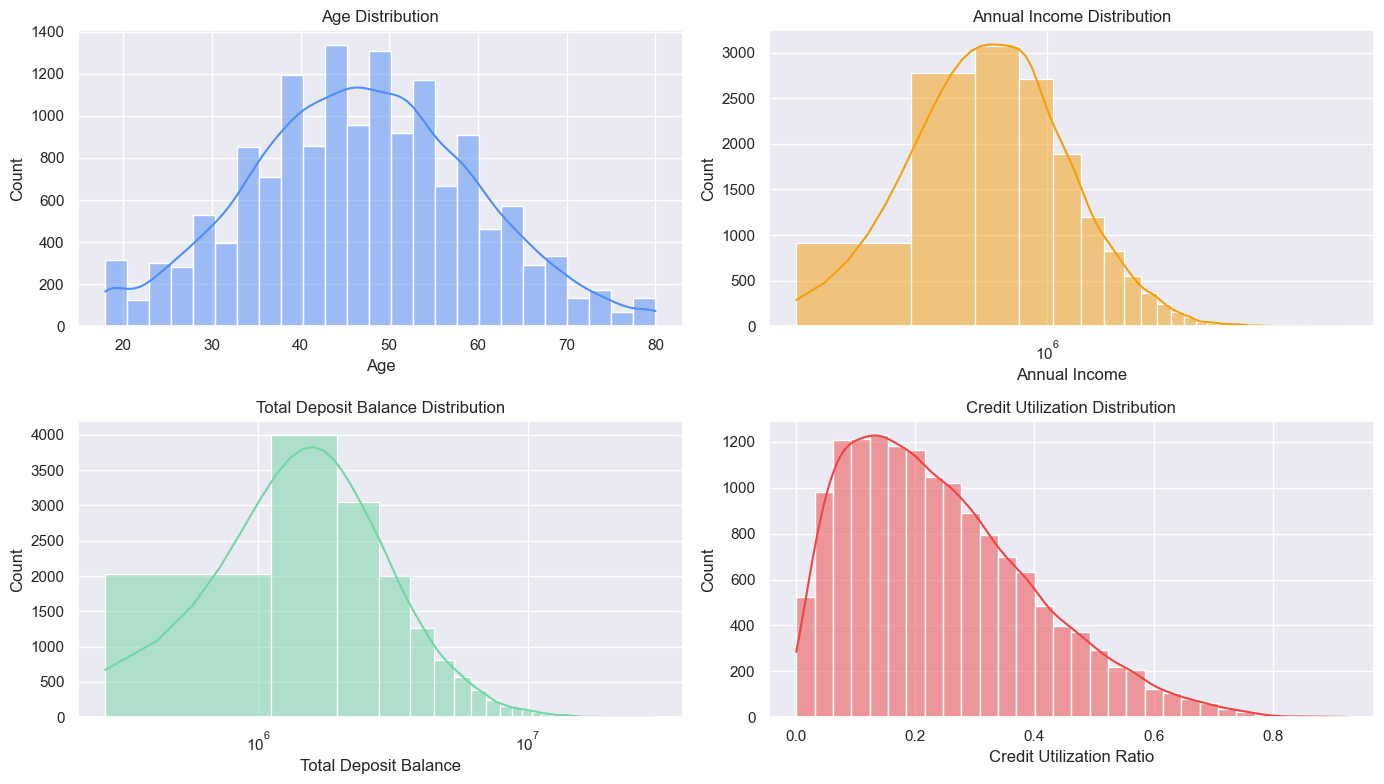

In [21]:
# Distribution plots for important customer fields.
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

sns.histplot(df["age"], bins=25, kde=True, ax=axes[0], color="#4f8ef7")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.histplot(df["annual_income"], bins=35, kde=True, ax=axes[1], color="#f59e0b")
axes[1].set_title("Annual Income Distribution")
axes[1].set_xlabel("Annual Income")
axes[1].set_xscale("log")

sns.histplot(df["total_deposit_balance"], bins=35, kde=True, ax=axes[2], color="#72d6a3")
axes[2].set_title("Total Deposit Balance Distribution")
axes[2].set_xlabel("Total Deposit Balance")
axes[2].set_xscale("log")

sns.histplot(df["credit_utilization_ratio"], bins=30, kde=True, ax=axes[3], color="#ef4444")
axes[3].set_title("Credit Utilization Distribution")
axes[3].set_xlabel("Credit Utilization Ratio")

fig.tight_layout()
fig.savefig(figures_dir / "customer_distribution_checks.png", dpi=160, bbox_inches="tight")
plt.show()



### Distribution Result
The customer base is mostly middle-aged, middle-income, and moderate-credit-usage customers, with a smaller high-value group holding higher income and deposits. This supports customer segmentation, premium banking targeting, and credit-risk monitoring.





### 11.2 Boxplots by Segment

Boxplots show value spread, not just average or median. This is useful because customer value is usually uneven inside each customer segment.


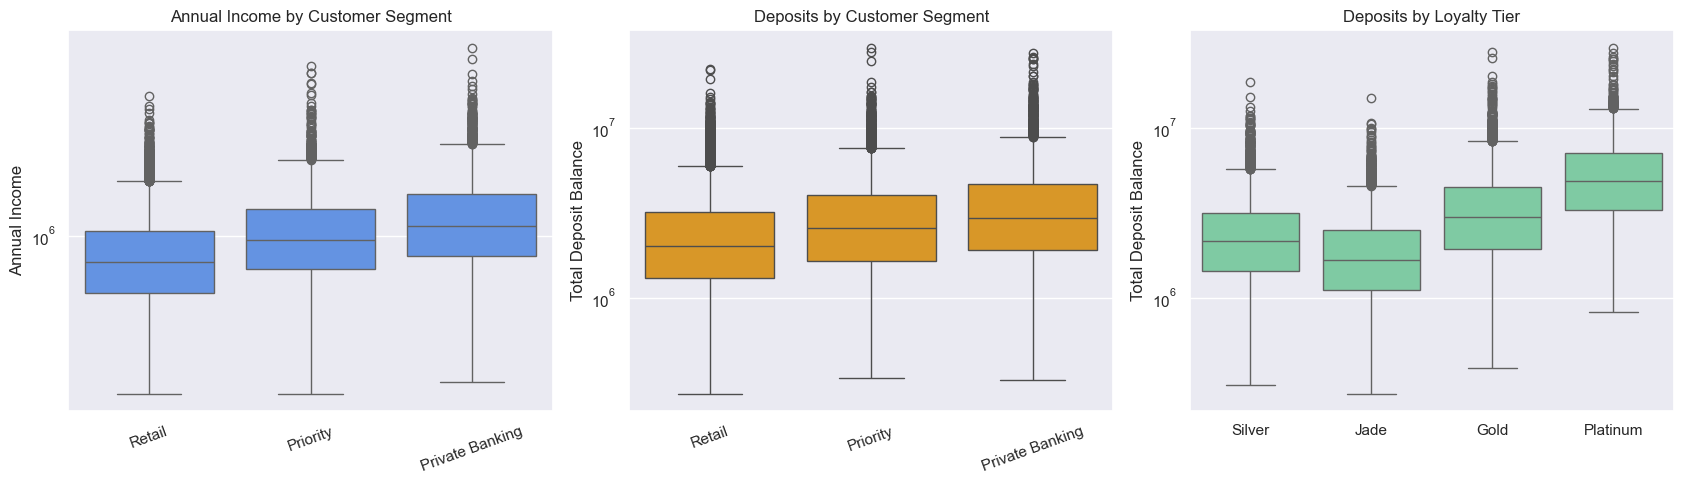

In [22]:
# Boxplots for income and deposits by customer segment.
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(data=df, x="customer_segment", y="annual_income", order=segment_order, ax=axes[0], color="#4f8ef7")
axes[0].set_title("Annual Income by Customer Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Annual Income")
axes[0].set_yscale("log")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="customer_segment", y="total_deposit_balance", order=segment_order, ax=axes[1], color="#f59e0b")
axes[1].set_title("Deposits by Customer Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Deposit Balance")
axes[1].set_yscale("log")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="loyalty_classification", y="total_deposit_balance", ax=axes[2], color="#72d6a3")
axes[2].set_title("Deposits by Loyalty Tier")
axes[2].set_xlabel("")
axes[2].set_ylabel("Total Deposit Balance")
axes[2].set_yscale("log")

fig.tight_layout()
fig.savefig(figures_dir / "customer_value_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()



### Boxplot Result

The bank’s highest-value customers are concentrated in Private Banking and Platinum loyalty tiers. Retail gives customer volume, but Private Banking and Platinum customers bring stronger income and deposit value.


### 11.3 Scatter Plot Relationships

Scatter plots help check whether two numeric fields move together. Here I compare income, deposits, and credit utilization.


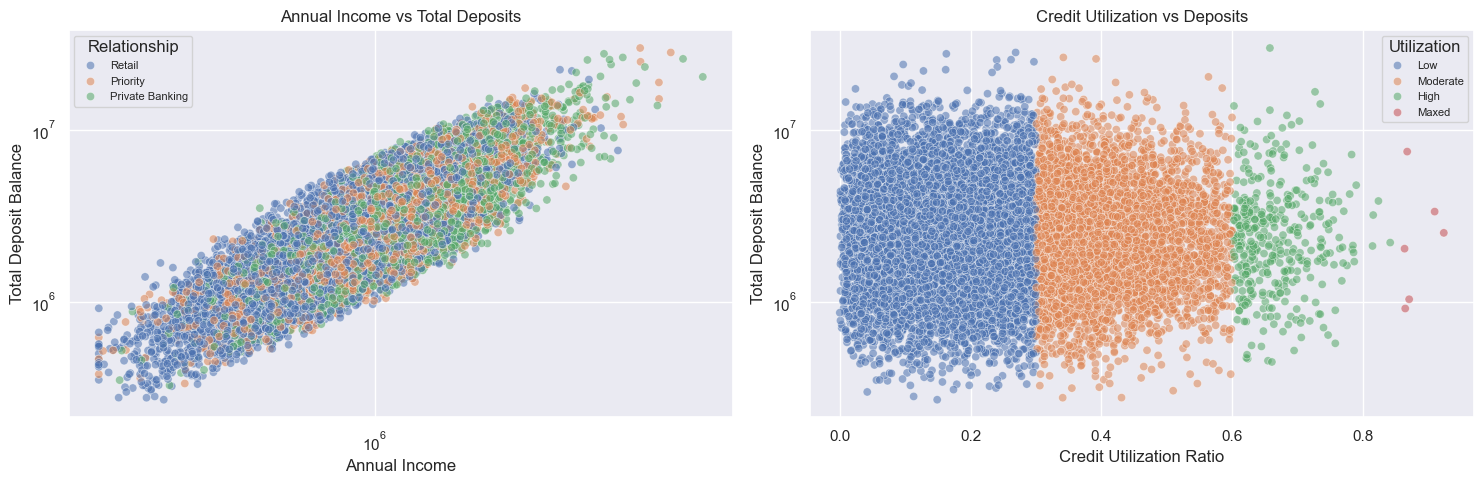

In [23]:
# Scatter plots for important customer relationships.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="total_deposit_balance",
    hue="customer_segment",
    alpha=0.55,
    ax=axes[0],
)
axes[0].set_title("Annual Income vs Total Deposits")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Total Deposit Balance")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].legend(title="Relationship", fontsize=8)

sns.scatterplot(
    data=df,
    x="credit_utilization_ratio",
    y="total_deposit_balance",
    hue="credit_utilization_band",
    alpha=0.55,
    ax=axes[1],
)
axes[1].set_title("Credit Utilization vs Deposits")
axes[1].set_xlabel("Credit Utilization Ratio")
axes[1].set_ylabel("Total Deposit Balance")
axes[1].set_yscale("log")
axes[1].legend(title="Utilization", fontsize=8)

fig.tight_layout()
fig.savefig(figures_dir / "customer_scatter_relationships.png", dpi=160, bbox_inches="tight")
plt.show()



### Scatter Plot Result

Income and deposits generally rise together, but there is still spread inside every segment. Credit utilization is mostly low or moderate for most customers.



### 11.4 Donut Charts for Portfolio Share

Donut charts are useful here because they show the share of each segment in the customer base.


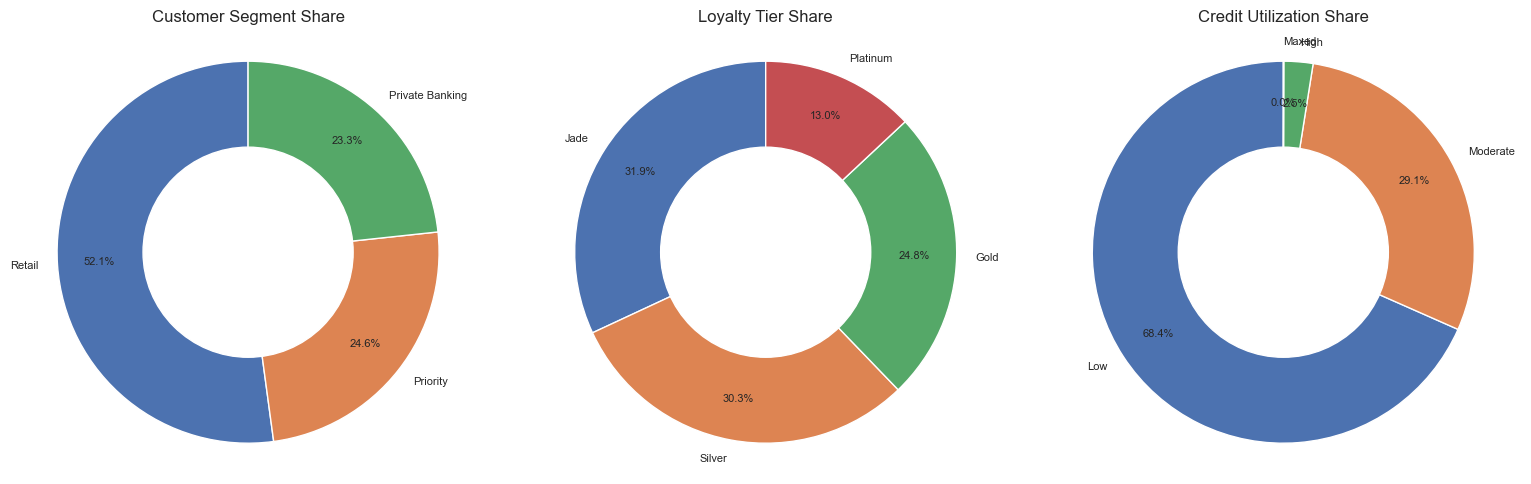

In [24]:
# Donut charts for customer segment, loyalty, and credit utilization share.
segment_counts = df["customer_segment"].value_counts().reindex(segment_order)
loyalty_counts = df["loyalty_classification"].value_counts()
utilization_counts = df["credit_utilization_band"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_donut_chart(axes[0], segment_counts.index, segment_counts.values, "Customer Segment Share")
plot_donut_chart(axes[1], loyalty_counts.index, loyalty_counts.values, "Loyalty Tier Share")
plot_donut_chart(axes[2], utilization_counts.index, utilization_counts.values, "Credit Utilization Share")
fig.tight_layout()
fig.savefig(figures_dir / "customer_segment_donut_charts.png", dpi=160, bbox_inches="tight")
plt.show()


### Portfolio Mix Result

The donut charts compare customer segment share, loyalty-tier share, and credit-utilization share without treating customer segment and loyalty as the same concept.


### 11.5 Heatmaps for Cross-Segment Patterns

The heatmaps compare customer segment with loyalty tier and income band. This shows how engagement and financial position vary within each service tier.


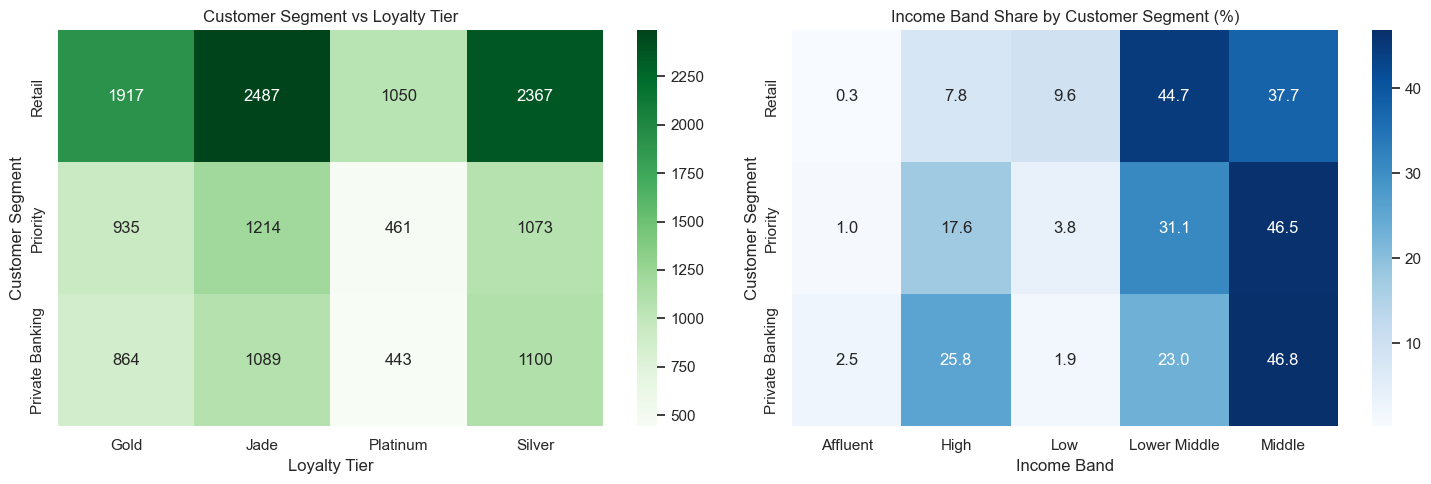

loyalty_classification,Gold,Jade,Platinum,Silver
customer_segment,,,,
Retail,1917,2487,1050,2367
Priority,935,1214,461,1073
Private Banking,864,1089,443,1100


income_band,Affluent,High,Low,Lower Middle,Middle
customer_segment,,,,,
Retail,0.26,7.79,9.62,44.66,37.68
Priority,0.98,17.65,3.80,31.06,46.51
Private Banking,2.52,25.77,1.89,23.00,46.82


In [25]:
# Relationship vs loyalty count heatmap.
segment_loyalty_matrix = pd.crosstab(
    df["customer_segment"],
    df["loyalty_classification"],
)

# Relationship vs income band percentage heatmap.
segment_income_pct = pd.crosstab(
    df["customer_segment"],
    df["income_band"],
    normalize="index",
).mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(segment_loyalty_matrix, annot=True, fmt="d", cmap="Greens", ax=axes[0])
axes[0].set_title("Customer Segment vs Loyalty Tier")
axes[0].set_xlabel("Loyalty Tier")
axes[0].set_ylabel("Customer Segment")

sns.heatmap(segment_income_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Income Band Share by Customer Segment (%)")
axes[1].set_xlabel("Income Band")
axes[1].set_ylabel("Customer Segment")

fig.tight_layout()
fig.savefig(figures_dir / "customer_segment_heatmaps.png", dpi=160, bbox_inches="tight")
plt.show()

display(segment_loyalty_matrix)
display(segment_income_pct)



### Segment Mix Result

The heatmaps show how loyalty and income groups are distributed inside each customer segment. This gives a better view than only looking at total customer counts.



### 11.6 Occupation Value Check

Customer count alone is not enough. This chart checks which occupations have higher median deposits among common occupations.


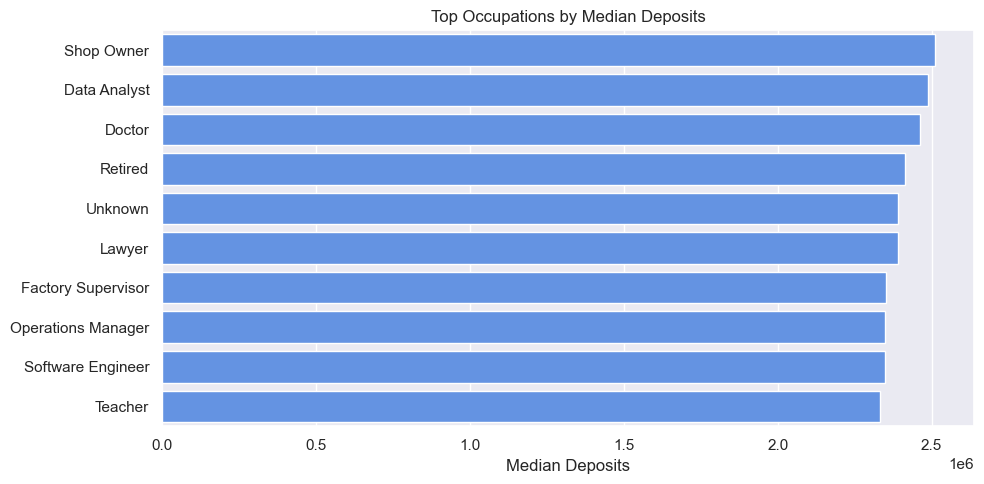

,occupation,customers,median_income,median_deposits
0,Shop Owner,822,"912,710.15","2,512,022.33"
1,Data Analyst,792,"891,442.28","2,488,368.04"
2,Doctor,857,"890,030.93","2,461,199.72"
3,Retired,877,"882,612.94","2,413,327.43"
4,Unknown,150,"847,260.89","2,391,857.48"
5,Lawyer,813,"866,652.62","2,389,137.13"
6,Factory Supervisor,831,"874,386.72","2,351,409.49"
7,Operations Manager,822,"874,386.72","2,349,642.70"
8,Software Engineer,845,"881,398.42","2,348,471.71"
9,Teacher,826,"874,386.72","2,332,605.04"


In [26]:
# Top occupations by median deposits, only where enough customers exist.
occupation_value_summary = (
    df.groupby("occupation", observed=False)
    .agg(
        customers=("customer_id", "count"),
        median_income=("annual_income", "median"),
        median_deposits=("total_deposit_balance", "median"),
    )
    .query("customers >= 50")
    .sort_values("median_deposits", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=occupation_value_summary.head(10), y="occupation", x="median_deposits", ax=ax, color="#4f8ef7")
ax.set_title("Top Occupations by Median Deposits")
ax.set_xlabel("Median Deposits")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(figures_dir / "top_occupations_by_deposit_value.png", dpi=160, bbox_inches="tight")
plt.show()

occupation_value_summary.head(10)



### Occupation Value Result

This compares occupations by deposit value, not only by count. It helps separate common occupations from financially stronger customer groups.



## 12. Final Customer Segment Insights

This section keeps the main customer-segment findings in one place.



In [27]:
# Pull key values from the summary tables.
largest_age_group = age_group_summary.sort_values("customers", ascending=False).iloc[0]
largest_segment = customer_segment_summary.sort_values("customers", ascending=False).iloc[0]
highest_deposit_segment = customer_segment_summary.sort_values("median_deposits", ascending=False).iloc[0]
highest_deposit_loyalty = loyalty_summary.sort_values("median_deposits", ascending=False).iloc[0]
largest_utilization_band = credit_utilization_summary.sort_values("customers", ascending=False).iloc[0]
highest_value_occupation = occupation_value_summary.sort_values("median_deposits", ascending=False).iloc[0]

customer_segment_insights = pd.DataFrame([
    {
        "finding": "Largest age group",
        "result": f"{largest_age_group['age_group']} with {int(largest_age_group['customers']):,} customers"
    },
    {
        "finding": "Largest customer segment",
        "result": f"{largest_segment['customer_segment']} with {int(largest_segment['customers']):,} customers ({largest_segment['customer_pct']:.2f}%)"
    },
    {
        "finding": "Highest median deposit customer segment",
        "result": f"{highest_deposit_segment['customer_segment']} with median deposits INR {highest_deposit_segment['median_deposits']:,.0f}"
    },
    {
        "finding": "Highest deposit loyalty tier",
        "result": f"{highest_deposit_loyalty['loyalty_classification']} with median deposits INR {highest_deposit_loyalty['median_deposits']:,.0f}"
    },
    {
        "finding": "Most common credit utilization band",
        "result": f"{largest_utilization_band['credit_utilization_band']} with {int(largest_utilization_band['customers']):,} customers"
    },
    {
        "finding": "Highest value common occupation",
        "result": f"{highest_value_occupation['occupation']} with median deposits INR {highest_value_occupation['median_deposits']:,.0f}"
    },
])

customer_segment_insights


,finding,result
0,Largest age group,"46-55 with 4,351 customers"
1,Largest customer segment,"Retail with 7,821 customers (52.14%)"
2,Highest median deposit customer segment,"Private Banking with median deposits INR 2,957..."
3,Highest deposit loyalty tier,"Platinum with median deposits INR 4,902,204"
4,Most common credit utilization band,"Low with 10,257 customers"
5,Highest value common occupation,"Shop Owner with median deposits INR 2,512,022"


### Insight Table Result

The final table summarizes the main customer findings: largest segment, strongest value segment, strongest loyalty tier, and overall credit-utilization pattern.



## 13. Export Tables

All tables are exported so they can be reused in the README, report, dashboard, or presentation.


In [28]:
export_tables(
    {
        "customer_kpis.csv": customer_kpis,
        "age_group_summary.csv": age_group_summary,
        "gender_summary.csv": gender_summary,
        "occupation_summary.csv": occupation_summary,
        "employment_summary.csv": employment_summary,
        "customer_segment_summary.csv": customer_segment_summary,
        "loyalty_summary.csv": loyalty_summary,
        "income_band_summary.csv": income_band_summary,
        "segment_income_summary.csv": segment_income_summary,
        "credit_utilization_summary.csv": credit_utilization_summary,
        "advisor_summary.csv": advisor_summary,
        "advisor_segment_summary.csv": advisor_segment_summary,
        "customer_segment_insights.csv": customer_segment_insights,
        "segment_loyalty_matrix.csv": segment_loyalty_matrix,
        "segment_income_pct.csv": segment_income_pct,
        "occupation_value_summary.csv": occupation_value_summary,
    },
    tables_dir,
)

exported_tables = pd.DataFrame([
    {"table": "customer_kpis.csv", "purpose": "overall customer portfolio KPIs"},
    {"table": "customer_segment_summary.csv", "purpose": "customer segment comparison"},
    {"table": "loyalty_summary.csv", "purpose": "loyalty tier value comparison"},
    {"table": "credit_utilization_summary.csv", "purpose": "credit utilization behavior"},
    {"table": "customer_segment_insights.csv", "purpose": "final interview-ready insights"},
])
exported_tables


,table,purpose
0,customer_kpis.csv,overall customer portfolio KPIs
1,customer_segment_summary.csv,customer segment comparison
2,loyalty_summary.csv,loyalty tier value comparison
3,credit_utilization_summary.csv,credit utilization behavior
4,customer_segment_insights.csv,final interview-ready insights


### Saved Outputs

The customer-segment tables and charts were saved successfully. These outputs explain the customer portfolio before moving into lending-risk analysis.



In [29]:
from IPython.display import Markdown

segment_display = customer_segment_summary.set_index("customer_segment")
segment_lines = []
for segment in segment_order:
    row = segment_display.loc[segment]
    segment_lines.append(
        f"- {segment}: **{int(row['customers']):,} customers ({row['customer_pct']:.2f}%)**, "
        f"median income **INR {row['median_income']:,.0f}**, "
        f"median deposits **INR {row['median_deposits']:,.0f}**, "
        f"median credit utilization **{row['median_credit_utilization']:.2%}**, "
        f"median tenure **{row['median_tenure_years']:.1f} years**"
    )

largest_segment = customer_segment_summary.sort_values("customers", ascending=False).iloc[0]
strongest_deposit_segment = customer_segment_summary.sort_values("median_deposits", ascending=False).iloc[0]
strongest_loyalty = loyalty_summary.sort_values("median_deposits", ascending=False).iloc[0]

final_summary = f"""
## 14. Final Summary

I analyzed **{len(df):,} individual customers** to compare demographic profile, service segment, income, deposits, loyalty, credit utilization, tenure, and advisor portfolios.

### Customer Segments

{chr(10).join(segment_lines)}

The largest service tier is **{largest_segment['customer_segment']}**, while **{strongest_deposit_segment['customer_segment']}** has the highest median deposits at **INR {strongest_deposit_segment['median_deposits']:,.0f}**.

### Loyalty and Credit Use

**{strongest_loyalty['loyalty_classification']}** has the highest median deposits among loyalty tiers at **INR {strongest_loyalty['median_deposits']:,.0f}**. Loyalty remains separate from customer segment: segment represents service level, while loyalty represents engagement strength.

Most customers are in low or moderate credit-utilization bands. Advisor-level and advisor-by-segment outputs show how customer count and deposit value are distributed across relationship managers.

This analysis distinguishes portfolio size from customer value and gives the bank a clearer basis for service planning, retention, cross-selling, and lending review.
"""
display(Markdown(final_summary))



## 14. Final Summary

I analyzed **15,000 individual customers** to compare demographic profile, service segment, income, deposits, loyalty, credit utilization, tenure, and advisor portfolios.

### Customer Segments

- Retail: **7,821 customers (52.14%)**, median income **INR 753,707**, median deposits **INR 2,012,535**, median credit utilization **21.80%**, median tenure **14.3 years**
- Priority: **3,683 customers (24.55%)**, median income **INR 958,939**, median deposits **INR 2,587,763**, median credit utilization **21.30%**, median tenure **14.0 years**
- Private Banking: **3,496 customers (23.31%)**, median income **INR 1,108,770**, median deposits **INR 2,957,191**, median credit utilization **21.40%**, median tenure **14.3 years**

The largest service tier is **Retail**, while **Private Banking** has the highest median deposits at **INR 2,957,191**.

### Loyalty and Credit Use

**Platinum** has the highest median deposits among loyalty tiers at **INR 4,902,204**. Loyalty remains separate from customer segment: segment represents service level, while loyalty represents engagement strength.

Most customers are in low or moderate credit-utilization bands. Advisor-level and advisor-by-segment outputs show how customer count and deposit value are distributed across relationship managers.

This analysis distinguishes portfolio size from customer value and gives the bank a clearer basis for service planning, retention, cross-selling, and lending review.
